In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [17]:
df = pd.read_csv("/content/drive/MyDrive/IMDb Movies India.csv.zip", encoding='latin1')

# required columns
df = df[['Genre', 'Director', 'Actor 1', 'Rating']]

# Drop missing values
df = df.dropna()

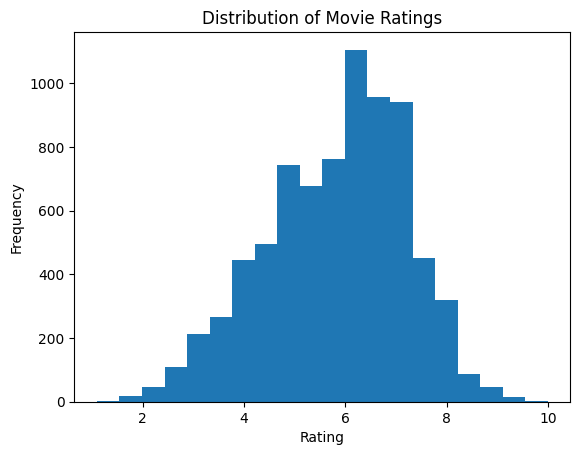

In [18]:
plt.figure()
plt.hist(df['Rating'], bins=20)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

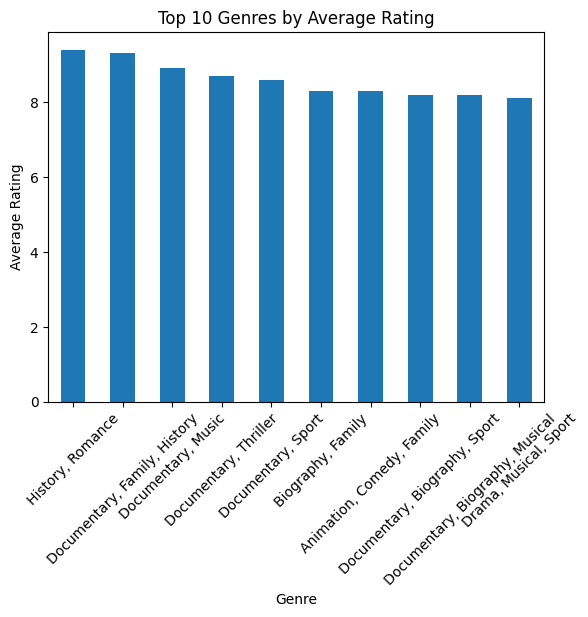

In [19]:
#Top 10 Genres by Average Rating
genre_avg = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure()
genre_avg.plot(kind='bar')
plt.title("Top 10 Genres by Average Rating")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

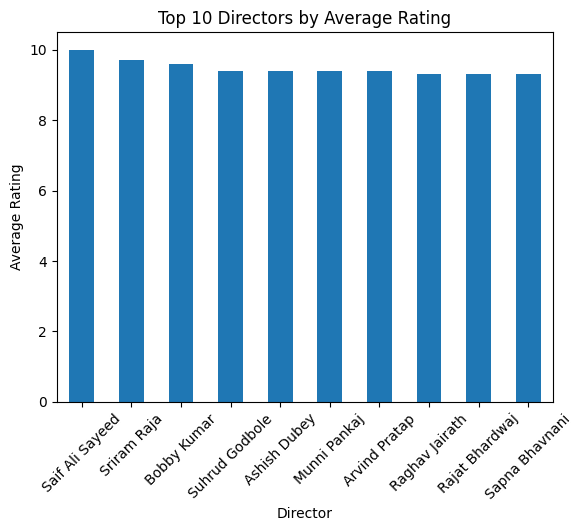

In [20]:
#Top 10 Directors by Average Rating
director_avg = df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure()
director_avg.plot(kind='bar')
plt.title("Top 10 Directors by Average Rating")
plt.xlabel("Director")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

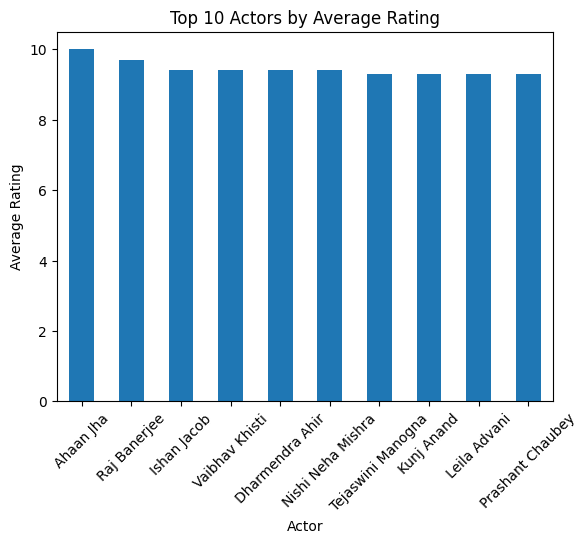

In [21]:
#Top 10 Actors by Average Rating
actor_avg = df.groupby('Actor 1')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure()
actor_avg.plot(kind='bar')
plt.title("Top 10 Actors by Average Rating")
plt.xlabel("Actor")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

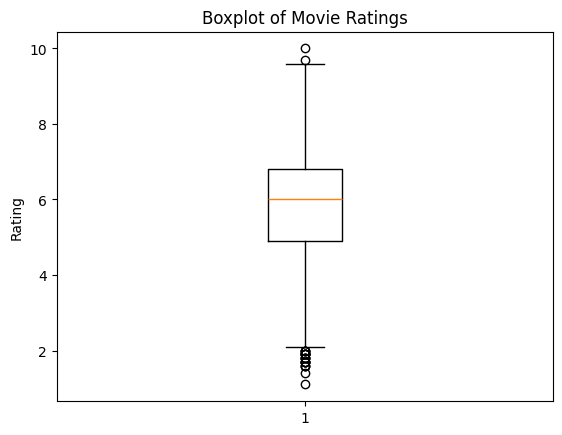

In [22]:
#Ratings vs Frequency (Box Plot)
plt.figure()
plt.boxplot(df['Rating'])
plt.title("Boxplot of Movie Ratings")
plt.ylabel("Rating")
plt.show()

In [23]:
# PREPROCESSING
le_genre = LabelEncoder()
le_director = LabelEncoder()
le_actor = LabelEncoder()

df['Genre'] = le_genre.fit_transform(df['Genre'])
df['Director'] = le_director.fit_transform(df['Director'])
df['Actor 1'] = le_actor.fit_transform(df['Actor 1'])

In [24]:
#MODEL BUILDING
X = df[['Genre', 'Director', 'Actor 1']]
y = df['Rating']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [26]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [27]:
#PREDICTION
y_pred = model.predict(X_test)

In [28]:
#EVALUATION
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 2.0509588933312055


In [29]:
#PREDICT NEW MOVIE
new_movie = pd.DataFrame([[1, 10, 25]], columns=['Genre', 'Director', 'Actor 1'])

predicted_rating = model.predict(new_movie)

print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 5.48091652802948
